In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import zivot_andrews
import statsmodels.api as sm

In [2]:
# Read in the processed dataset
file_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(file_path)

C:\Users\sbout\AppData\Local\Temp\ipykernel_24536\955667600.py:3: DtypeWarning: Columns (46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df.describe()

,county_fips,median_listing_price_x,median_listing_price_mm_x,median_listing_price_yy_x,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market_x,median_days_on_market_mm_x,median_days_on_market_yy_x,...,U.S. 30 year FRM,30 year fees & points,U.S. 15 year FRM,15 year fees & points,U.S. 5/1 ARM,5/1 year fees & points,U.S. 5/1 ARM margin,30 year FRM / 5/1 ARM spread,month,highest_category
count,360053.00000,3.600280e+05,322557.000000,321231.000000,360053.000000,322486.000000,321071.000000,359710.000000,322246.000000,320783.000000,...,360053.000000,238692.000000,360053.000000,238692.000000,238692.000000,238692.000000,238692.000000,238692.000000,34156.000000,31047.000000
mean,30307.92485,2.703053e+05,0.017487,0.120064,292.939042,0.009125,0.078057,74.318448,0.046456,0.100056,...,4.844304,0.611065,4.172829,0.590817,3.358747,0.339297,2.750027,0.563095,9.271900,2.802364
std,15154.92739,2.194439e+05,1.059819,0.935075,867.790716,0.192785,0.773584,35.048294,0.433508,1.373417,...,1.495556,0.128521,1.441222,0.157097,0.657493,0.070461,0.007652,0.360221,0.863141,1.326533
min,1001.00000,1.000000e+00,-0.997100,-0.996800,0.000000,-1.000000,-1.000000,1.000000,-0.996700,-0.994800,...,2.684000,0.440000,2.145000,0.400000,2.422500,0.200000,2.737500,-0.237500,8.000000,1.000000
25%,18167.00000,1.499250e+05,-0.027600,-0.032100,26.000000,-0.073500,-0.225800,50.000000,-0.092500,-0.193500,...,3.616000,0.500000,3.027500,0.480000,2.888000,0.300000,2.747500,0.300000,9.000000,2.000000
50%,29153.00000,2.250000e+05,0.000000,0.056400,74.000000,0.000000,-0.017500,68.000000,0.044900,-0.014300,...,4.444000,0.550000,3.906000,0.520000,3.226000,0.325000,2.750000,0.642500,9.000000,3.000000
75%,45063.00000,3.300000e+05,0.035000,0.174500,226.000000,0.066700,0.242700,92.000000,0.164600,0.196700,...,6.428000,0.700000,5.682000,0.680000,3.695000,0.400000,2.750000,0.792000,10.000000,4.000000
max,56045.00000,1.300000e+07,570.319600,222.874900,23258.000000,32.500000,91.500000,365.000000,114.000000,266.000000,...,7.620000,0.900000,6.905000,1.150000,6.005000,0.500000,2.770000,1.287500,11.000000,5.000000


In [4]:
# Convert time column into true Datetime objects so Matplotlib can shade specific date
df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y-%m-%d')

# Create a 'Region' column to split the dataset
df['Region'] = 'Rest of US'

# Change Region value to Florida for state_id = fl
df.loc[df['state'] == 'fl', 'Region'] = 'Florida' 

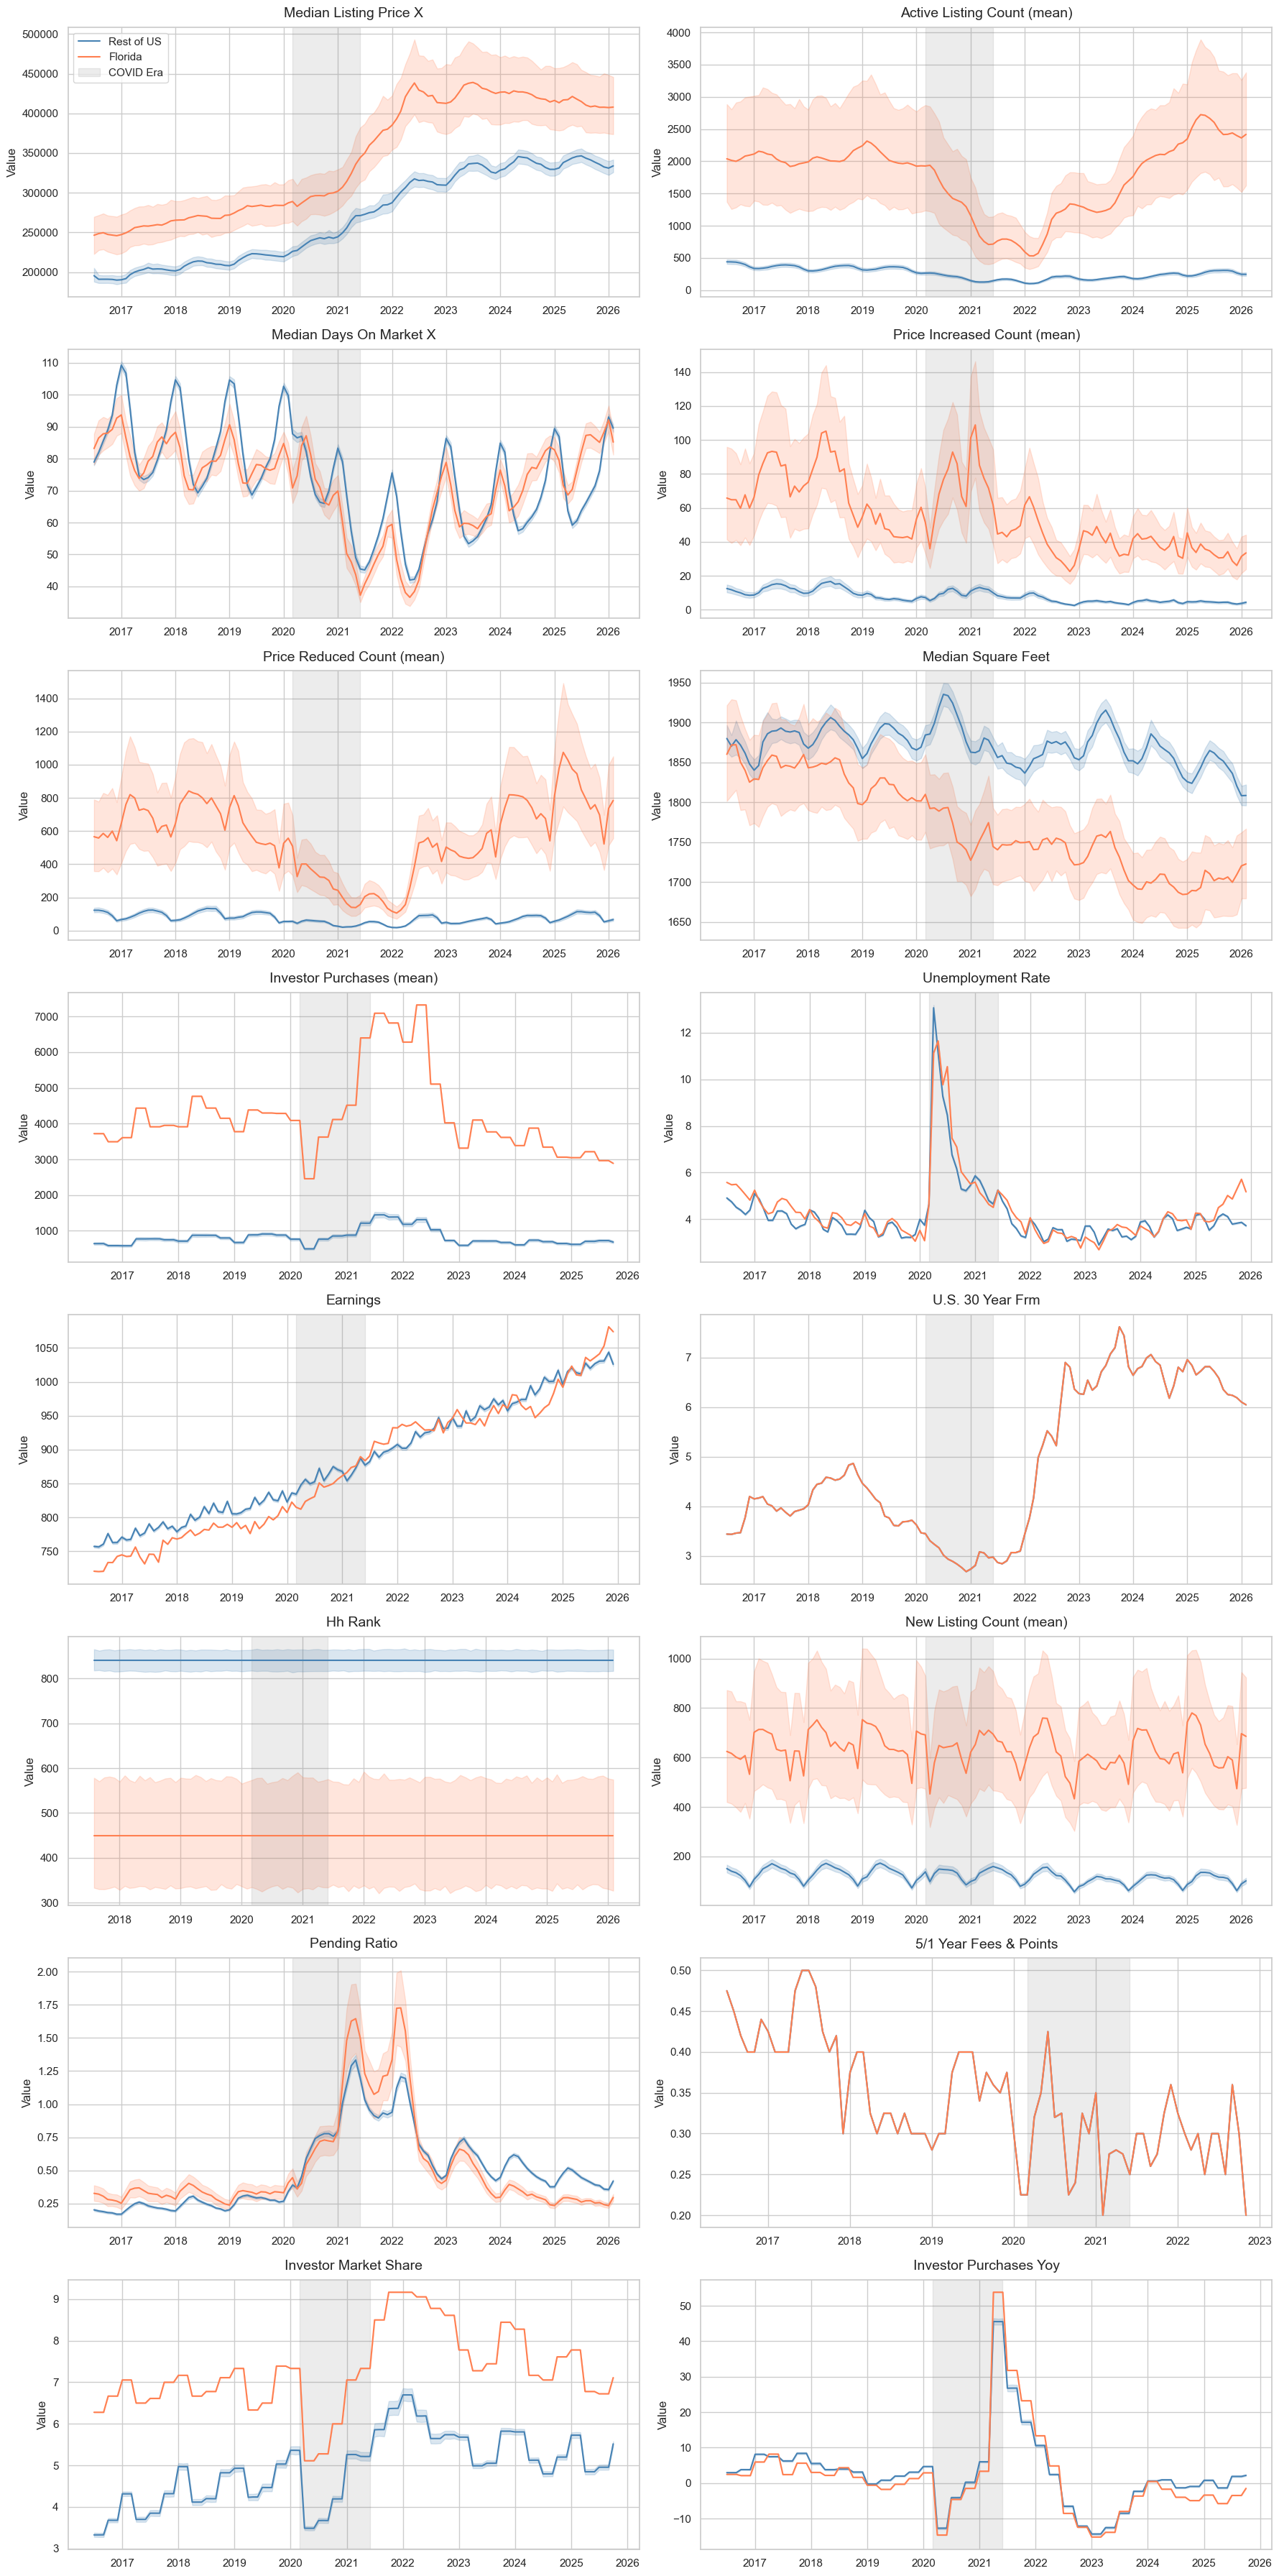

In [6]:
# Select relevant features to plot

columns_to_plot = [
    'median_listing_price_x', 'active_listing_count', 'median_days_on_market_x', 
    'price_increased_count', 'price_reduced_count', 'median_square_feet',  
    'Investor Purchases', 'Unemployment_Rate', 'Earnings', 'U.S. 30 year FRM',
    'hh_rank', 'new_listing_count', 'pending_ratio', '5/1 year fees & points',
    'Investor Market Share', 'Investor Purchases YoY'
]

# Set up plot
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(18, 36))
axes = axes.flatten()

# Define COVID era shading boundaries (Year-Month-Day)
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-05-31')

# The specific columns that need "(mean)" added to their title
mean_title_cols = [
    'active_listing_count', 
    'price_increased_count', 
    'price_reduced_count', 
    'new_listing_count', 
    'Investor Purchases'
]

# plot
for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # Plot both regions on the same axis (using the default mean estimator)
        sns.lineplot(
            data=df, x='date', y=col, hue='Region', 
            ax=axes[i], palette={'Florida': 'coral', 'Rest of US': 'steelblue'}
        )
        
        # Clean up the titles (e.g., changes 'median_listing_price_x' to 'Median Listing Price X')
        clean_title = col.replace('_', ' ').title()
        
        # APPEND "(mean)" IF IT IS A COUNT VARIABLE
        if col in mean_title_cols:
            clean_title += " (mean)"
            
        axes[i].set_title(clean_title, fontsize=14, pad=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Value')
        
        # Add the light shading for the COVID era
        axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)
        
        # Only keep the legend on the very first plot
        if i == 0:
            covid_patch = mpatches.Patch(color='gray', alpha=0.15, label='COVID Era')
            handles, labels = axes[i].get_legend_handles_labels()
            axes[i].legend(handles=handles + [covid_patch], loc='best')
        else:
            axes[i].get_legend().remove()
            
    else:
        axes[i].set_visible(False)
        print(f"Warning: Column '{col}' not found. Check capitalization!")

# Adjust the layout to keep it looking clean
plt.tight_layout()
plt.show()



C:\Users\sbout\AppData\Local\Temp\ipykernel_24536\1882337253.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['year_month'] = df2['date'].dt.to_period('M').astype(str)


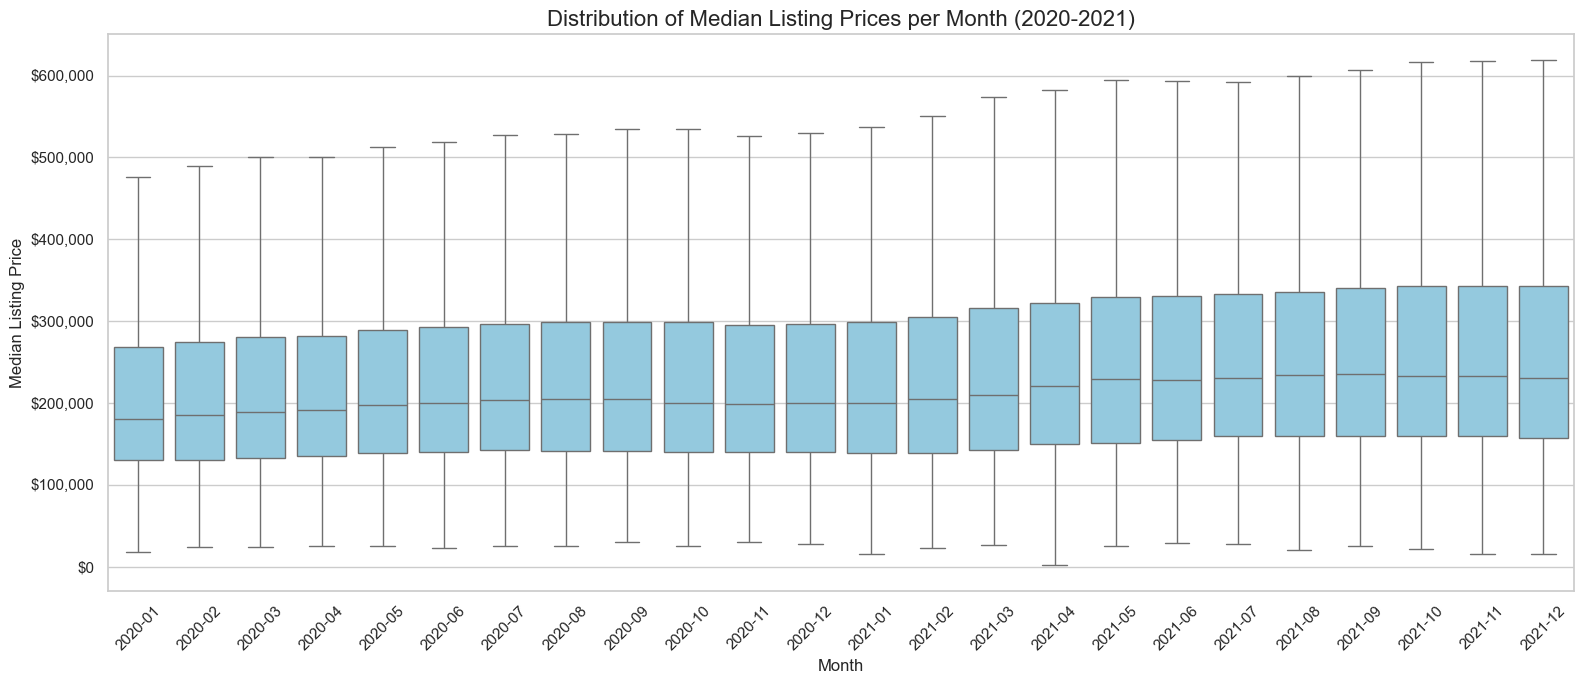

In [7]:
# filter out any missing prices
df = df.dropna(subset=['median_listing_price_x'])

# Extract Year-Month for grouping the X-axis labels (e.g., '2016-07')
df['year_month'] = df['date'].dt.to_period('M').astype(str)

# Filter for the specific years 2020 and 2021
df2 = df[(df['date'].dt.year >= 2020) & (df['date'].dt.year <= 2021)]

# Extract Year-Month for grouping the X-axis labels (e.g., '2020-07')
df2['year_month'] = df2['date'].dt.to_period('M').astype(str)

# Sort chronologically 
df2 = df2.sort_values('date')

# Create the Box Plot
plt.figure(figsize=(16, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=df2, 
    x='year_month', 
    y='median_listing_price_x', 
    color='skyblue',
    showfliers=False
)
# Format the plot for readability
plt.title('Distribution of Median Listing Prices per Month (2020-2021)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Median Listing Price', fontsize=12)
# Rotate X-axis labels to 45 degrees
plt.xticks(rotation=45)
# Format Y-axis ticks as dollar amounts
formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)
# Adjust layout
plt.tight_layout()
plt.show()


--- Augmented Dickey-Fuller Test: Whole US ---
ADF Statistic: -2.3664
p-value: 0.1515
=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).

--- Augmented Dickey-Fuller Test: Florida ---
ADF Statistic: -1.0623
p-value: 0.7299
=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).

--- Augmented Dickey-Fuller Test: Rest of US (excluding FL) ---
ADF Statistic: -2.5903
p-value: 0.0950
=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).



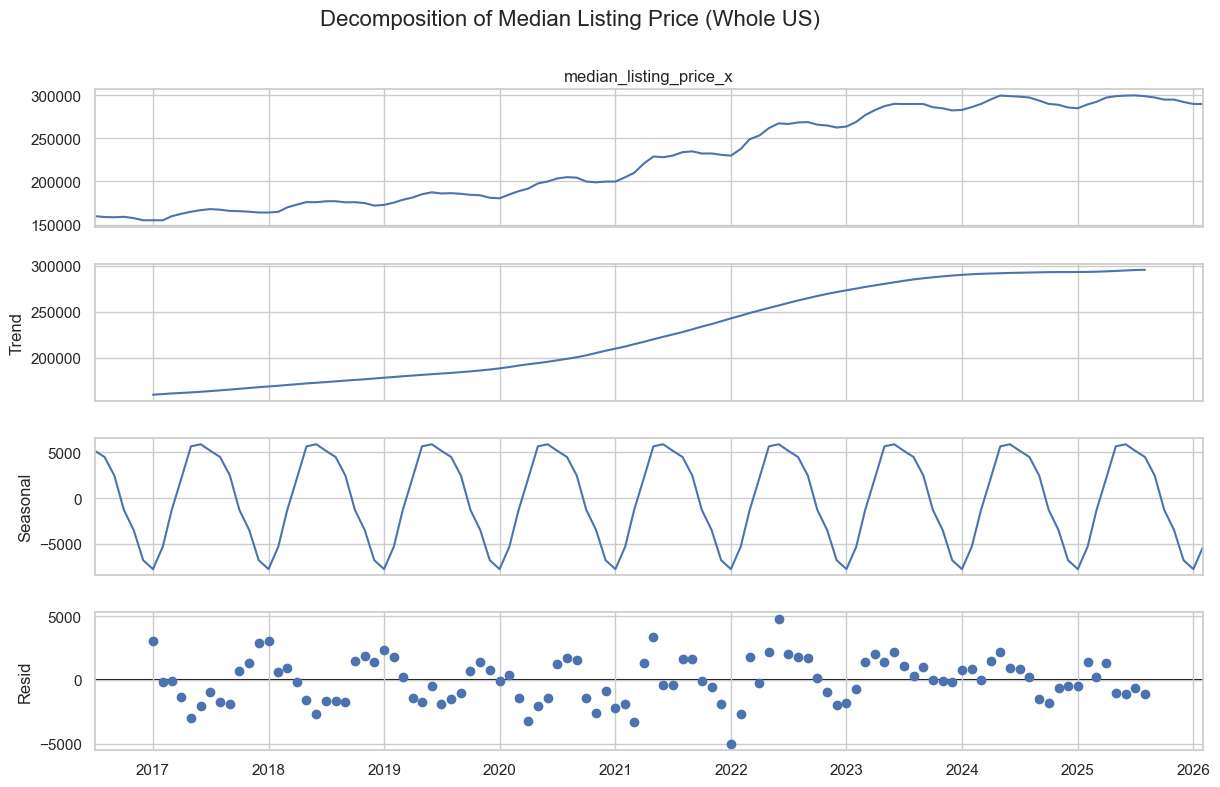

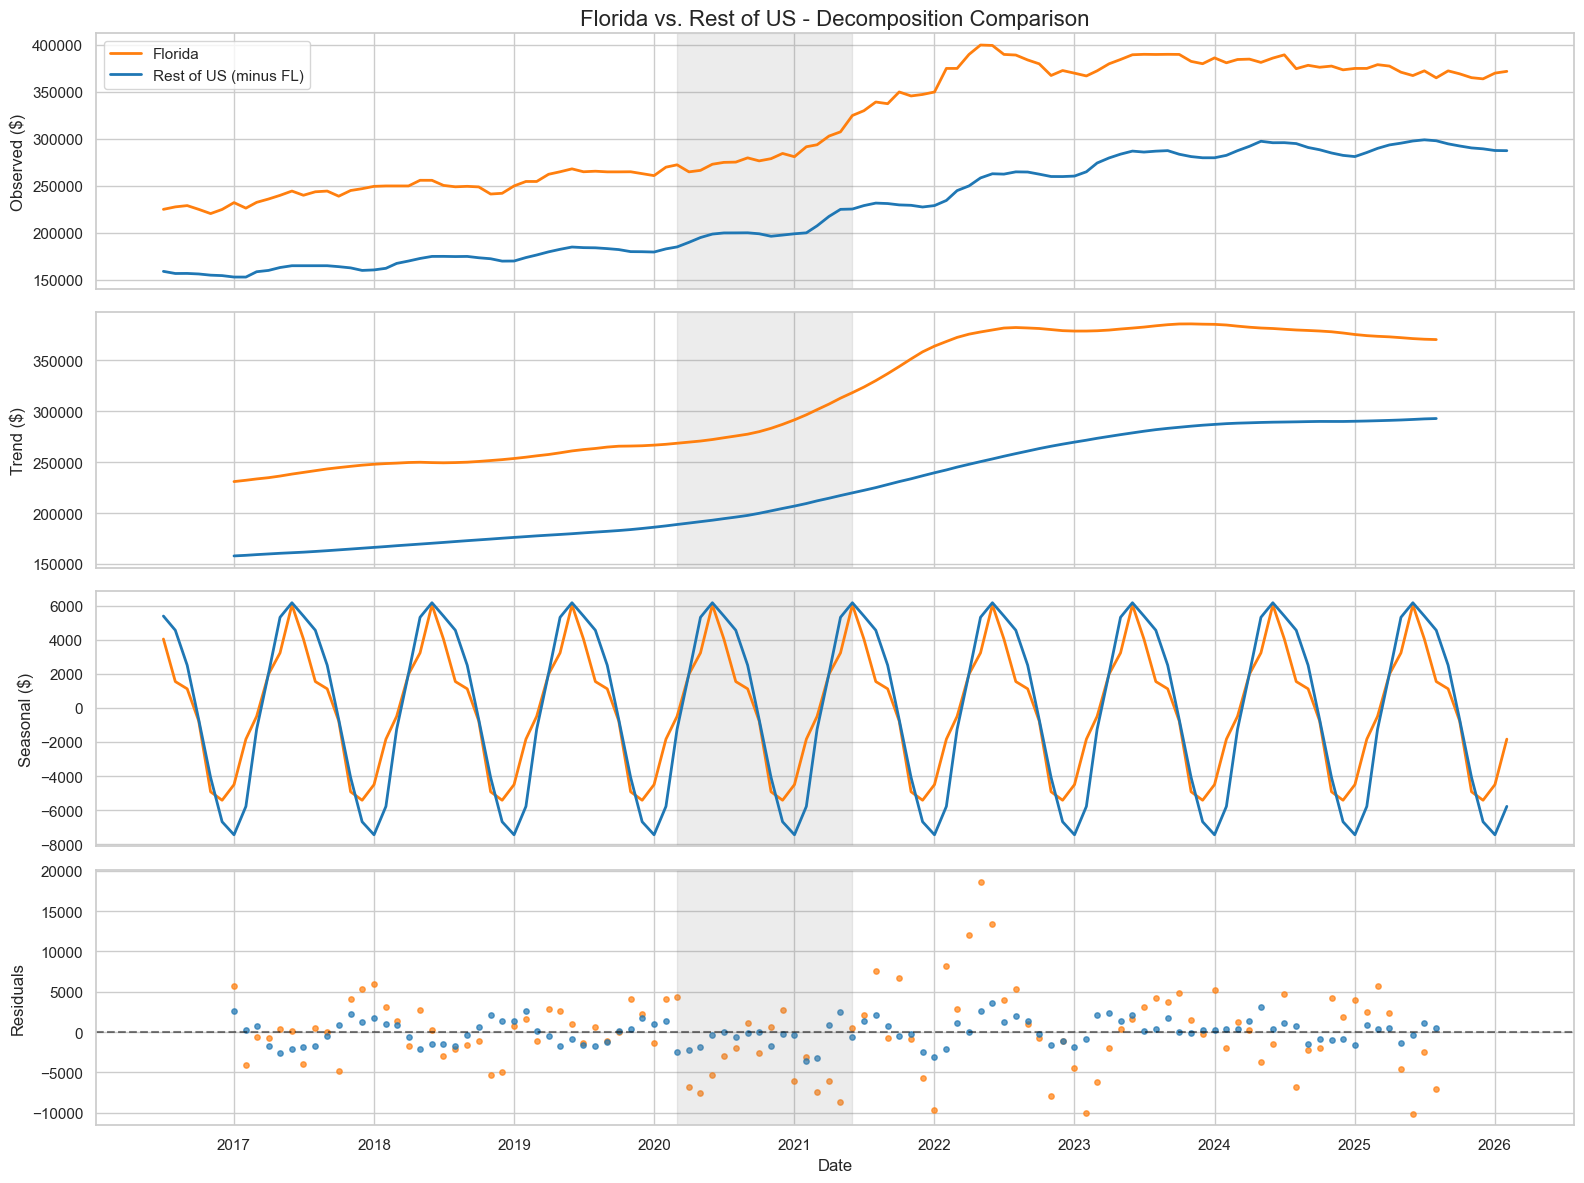

In [8]:
# Standardize state strings to lowercase to ensure clean filtering
df['state'] = df['state'].astype(str).str.lower()

# Helper function to generate a continuous monthly median series
def get_monthly_median_series(subset):
    # Group by date and calculate median of median listings for the selected region
    s = subset.groupby('date')['median_listing_price_x'].median()
    # Ensure a rigid Month-Start frequency (required by `seasonal_decompose`)
    s = s.sort_index().resample('MS').mean() 
    s = s.interpolate() # Safety interpolator in case any month was completely unrecorded
    return s
us_series   = get_monthly_median_series(df)
fl_series   = get_monthly_median_series(df[df['state'] == 'fl'])
rest_series = get_monthly_median_series(df[df['state'] != 'fl'])

# Stationarity Checks (Augmented Dickey-Fuller Test)
def print_adf_test(series, title):
    print(f"--- Augmented Dickey-Fuller Test: {title} ---")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    if result[1] <= 0.05:
        print("=> Reject the null hypothesis: The series is Stationary.\n")
    else:
        print("=> Fail to reject the null hypothesis: The series is Non-Stationary (has a unit root).\n")
print_adf_test(us_series, "Whole US")
print_adf_test(fl_series, "Florida")
print_adf_test(rest_series, "Rest of US (excluding FL)")

# Timeseries Decomposition
# Period is set to 12 representing 12 months in a yearly cycle
period = 12 
dec_us   = seasonal_decompose(us_series, model='additive', period=period)
dec_fl   = seasonal_decompose(fl_series, model='additive', period=period)
dec_rest = seasonal_decompose(rest_series, model='additive', period=period)

# Plotting
# Whole US Decomposition 
fig_us = dec_us.plot()
fig_us.set_size_inches(14, 8)
fig_us.suptitle('Decomposition of Median Listing Price (Whole US)', y=1.02, fontsize=16)
plt.show()

# Florida vs Rest of US (Minus FL) 
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
sns.set_theme(style="whitegrid")
# Brand colors for visual clarity
color_fl = '#ff7f0e' # Orange
color_rest = '#1f77b4' # Blue
# Observed
axes[0].plot(dec_fl.observed, label='Florida', color=color_fl, linewidth=2)
axes[0].plot(dec_rest.observed, label='Rest of US (minus FL)', color=color_rest, linewidth=2)
axes[0].set_ylabel('Observed ($)')
axes[0].set_title('Florida vs. Rest of US - Decomposition Comparison', fontsize=16)
axes[0].legend(loc='upper left')
# Trend
axes[1].plot(dec_fl.trend, label='Florida', color=color_fl, linewidth=2)
axes[1].plot(dec_rest.trend, label='Rest of US (minus FL)', color=color_rest, linewidth=2)
axes[1].set_ylabel('Trend ($)')
# Seasonal
axes[2].plot(dec_fl.seasonal, label='Florida', color=color_fl, linewidth=2)
axes[2].plot(dec_rest.seasonal, label='Rest of US (minus FL)', color=color_rest, linewidth=2)
axes[2].set_ylabel('Seasonal ($)')
# Residuals
axes[3].scatter(dec_fl.resid.index, dec_fl.resid, label='Florida', color=color_fl, s=15, alpha=0.7)
axes[3].scatter(dec_rest.resid.index, dec_rest.resid, label='Rest of US (minus FL)', color=color_rest, s=15, alpha=0.7)
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Date')

 # Add the light shading for the COVID era
for i in range(4):
    axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)

plt.tight_layout()
plt.show()

Trend Growth (Jan 2017 to Aug 2025)
Florida Trend Growth:      60.47%
Rest of US Trend Growth:   85.60%
Florida's trend lagged behind the Rest of US by ( 25.12 ) percentage points.

Correlation
Pearson Correlation (FL vs Rest of US): 0.9750
(1.0 = Perfect positive linear relationship)

Cointegration Test
p-value: 0.5478
=> Result: NOT Cointegrated.
=> Meaning: Florida is experiencing an independent structural drift that has completely decoupled from the national market baseline.


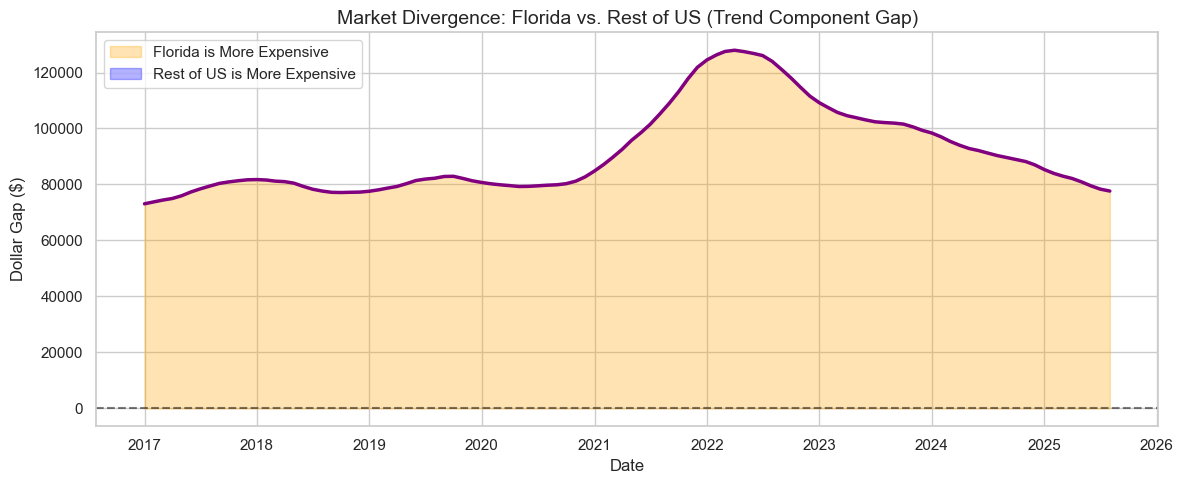

In [9]:
# Align both trend series tightly by date and drop missing ends (caused by the moving average window)
aligned_trends = pd.concat([dec_fl.trend, dec_rest.trend], axis=1).dropna()
aligned_trends.columns = ['FL_Trend', 'Rest_us_Trend']
fl_trend_clean = aligned_trends['FL_Trend'] # Florida
rest_trend_clean = aligned_trends['Rest_us_Trend'] # Rest of US

# Total Trend Growth (%)
fl_start, fl_end = fl_trend_clean.iloc[0], fl_trend_clean.iloc[-1]
rest_start, rest_end = rest_trend_clean.iloc[0], rest_trend_clean.iloc[-1]
fl_growth = (fl_end - fl_start) / fl_start * 100
rest_growth = (rest_end - rest_start) / rest_start * 100
print(f"Trend Growth ({fl_trend_clean.index[0].strftime('%b %Y')} to {fl_trend_clean.index[-1].strftime('%b %Y')})")
print(f"Florida Trend Growth:      {fl_growth:.2f}%")
print(f"Rest of US Trend Growth:   {rest_growth:.2f}%")
if fl_growth > rest_growth:
    print(f"Florida's trend outpaced the Rest of US by ( {fl_growth - rest_growth:.2f} ) percentage points.\n")
else:
    print(f"Florida's trend lagged behind the Rest of US by ( {rest_growth - fl_growth:.2f} ) percentage points.\n")

# Correlation
trend_corr = fl_trend_clean.corr(rest_trend_clean)
print(f"Correlation")
print(f"Pearson Correlation (FL vs Rest of US): {trend_corr:.4f}")
print("(1.0 = Perfect positive linear relationship)\n")

# Cointegration (Engle-Granger) Test
score, pval, _ = coint(fl_trend_clean, rest_trend_clean)
print(f"Cointegration Test")
print(f"p-value: {pval:.4f}")
if pval <= 0.05:
    print("=> Result: Cointegrated.")
    print("=> Meaning: Even though prices fluctuate, Florida and the US are bound by a stable long-term relationship. The price gap between them is mean-reverting.")
else:
    print("=> Result: NOT Cointegrated.")
    print("=> Meaning: Florida is experiencing an independent structural drift that has completely decoupled from the national market baseline.")
    
# Visualize the gap
plt.figure(figsize=(12, 5))
# Calculate the running difference between FL and the Rest of the US
trend_spread = fl_trend_clean - rest_trend_clean
plt.plot(trend_spread.index, trend_spread, color='purple', linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
# Color the under/over performance
plt.fill_between(trend_spread.index, trend_spread, 0, where=(trend_spread > 0), 
                 color='orange', alpha=0.3, label="Florida is More Expensive")
plt.fill_between(trend_spread.index, trend_spread, 0, where=(trend_spread < 0), 
                 color='blue', alpha=0.3, label="Rest of US is More Expensive")
# Formatting
plt.title('Market Divergence: Florida vs. Rest of US (Trend Component Gap)', fontsize=14)
plt.ylabel('Dollar Gap ($)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

--- 🔮 Optimal Prediction Lags 🔮 ---
Whole US:        Inventory changes predict Prices best at a 3-month lag (r = -0.723)
Florida:         Inventory changes predict Prices best at a 3-month lag (r = -0.526)
Rest of US:      Inventory changes predict Prices best at a 3-month lag (r = -0.723)



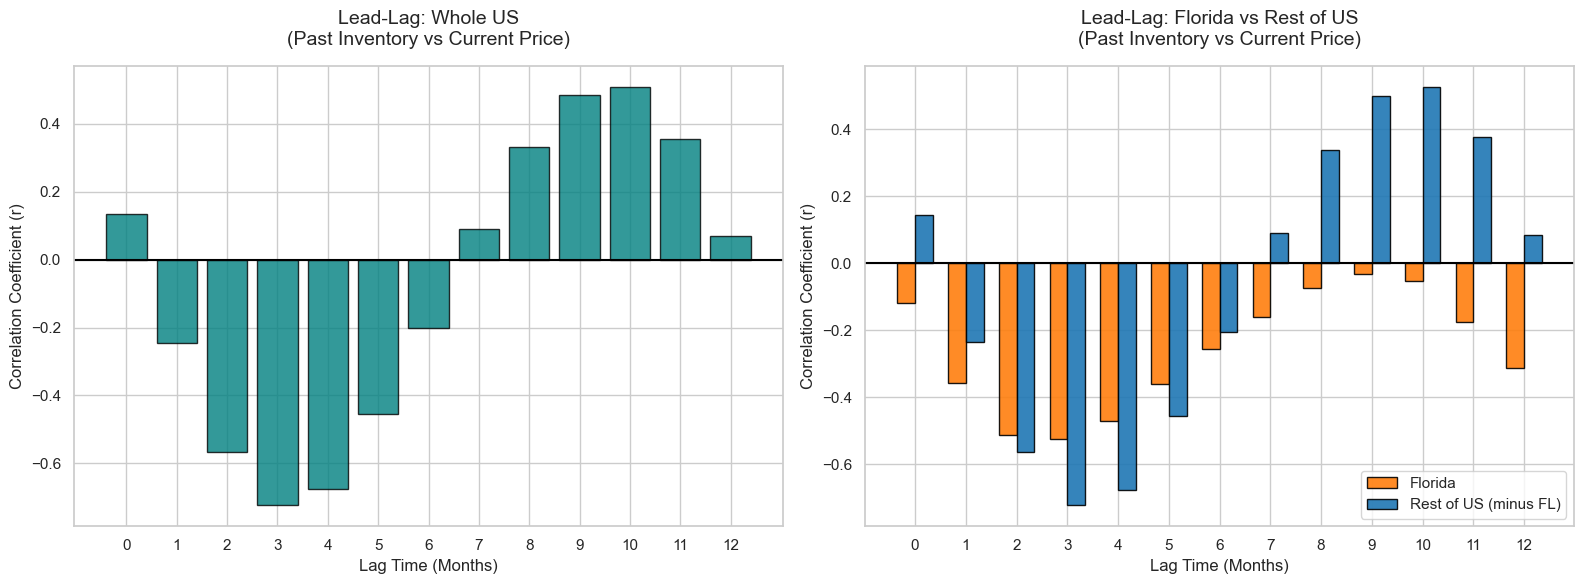

In [10]:
df = df.dropna(subset=['median_listing_price_mm_x', 'active_listing_count_mm'])

# Helper function to generate stationary series from the MM metrics
def get_stationary_series(subset):
    # Group by date to find the typical "median" month-over-month change across the region
    agg_df = subset.groupby('date')[['median_listing_price_mm_x', 'active_listing_count_mm']].median()
    
    # Ensure a rigid Month-Start frequency for robust cross-correlation shifting
    stat_df = agg_df.sort_index().resample('MS').mean().interpolate()
    return stat_df
us_df = get_stationary_series(df)
fl_df = get_stationary_series(df[df['state'] == 'fl'])
rest_df = get_stationary_series(df[df['state'] != 'fl'])
# Calculate Cross-Correlations for up to 12 Months of lag
def calculate_lead_lags(df, lags=12):
    results = []
    # Target = Price Change (mm), Predictor = Inventory Change (mm) from lag months ago
    for lag in range(0, lags + 1):
        # Shift inventory forward: A negative correlation is expected (shrinking inventory = rising prices)
        corr = df['median_listing_price_mm_x'].corr(df['active_listing_count_mm'].shift(lag))
        results.append({'Lag_Months': lag, 'Correlation': corr})
    return pd.DataFrame(results)
us_ccf = calculate_lead_lags(us_df)
fl_ccf = calculate_lead_lags(fl_df)
rest_ccf = calculate_lead_lags(rest_df)

# Identify the Optimal Predictive Lags
print("--- 🔮 Optimal Prediction Lags 🔮 ---")
opt_us = us_ccf.loc[us_ccf['Correlation'].idxmin()]
print(f"Whole US:        Inventory changes predict Prices best at a {int(opt_us['Lag_Months'])}-month lag (r = {opt_us['Correlation']:.3f})")
opt_fl = fl_ccf.loc[fl_ccf['Correlation'].idxmin()]
print(f"Florida:         Inventory changes predict Prices best at a {int(opt_fl['Lag_Months'])}-month lag (r = {opt_fl['Correlation']:.3f})")
opt_rest = rest_ccf.loc[rest_ccf['Correlation'].idxmin()]
print(f"Rest of US:      Inventory changes predict Prices best at a {int(opt_rest['Lag_Months'])}-month lag (r = {opt_rest['Correlation']:.3f})\n")

# Plot the Cross-Correlation Bar Charts
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Whole US
plt.subplot(1, 2, 1)
plt.bar(us_ccf['Lag_Months'], us_ccf['Correlation'], color='teal', alpha=0.8, edgecolor='black')
plt.axhline(0, color='black', linewidth=1.5)
plt.title('Lead-Lag: Whole US\n(Past Inventory vs Current Price)', fontsize=14, pad=15)
plt.xlabel('Lag Time (Months)')
plt.ylabel('Correlation Coefficient (r)')
plt.xticks(range(0, 13))

# Florida vs Rest of US
plt.subplot(1, 2, 2)
width = 0.35
x = np.arange(len(fl_ccf['Lag_Months']))
plt.bar(x - width/2, fl_ccf['Correlation'], width, label='Florida', color=color_fl, alpha=0.9, edgecolor='black')
plt.bar(x + width/2, rest_ccf['Correlation'], width, label='Rest of US (minus FL)', color=color_rest, alpha=0.9, edgecolor='black')
plt.axhline(0, color='black', linewidth=1.5)
plt.title('Lead-Lag: Florida vs Rest of US\n(Past Inventory vs Current Price)', fontsize=14, pad=15)
plt.xlabel('Lag Time (Months)')
plt.ylabel('Correlation Coefficient (r)')
plt.xticks(x, fl_ccf['Lag_Months'])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

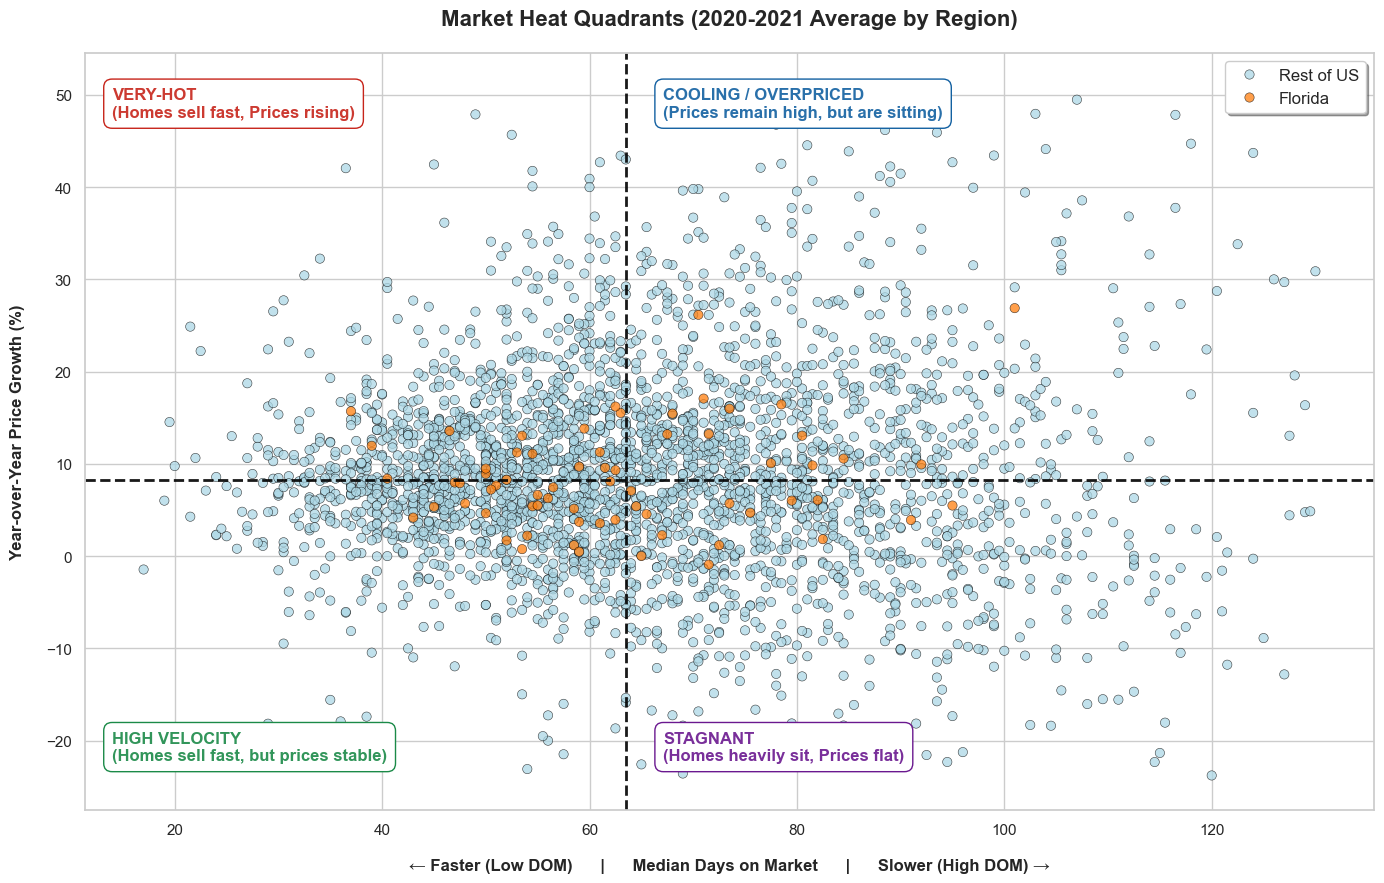

Percentage of Florida Counties existing inside the 'Hyper-Hot' Sector: 23.9%



In [11]:
# Prep Data from 2020-2021 set

df2 = df2.dropna(subset=['median_days_on_market_x', 'median_listing_price_yy_x'])

# Establish Region flags for Florida vs US
df2['state'] = df2['state'].astype(str).str.lower()
df2['Region'] = df2['state'].apply(lambda x: 'Florida' if x == 'fl' else 'Rest of US')


# Aggregate 1 Dot per County 
# Taking the median across all 2020-2021 months represents the county's "typical" pandemic market heat
county_heat = df2.groupby(['county_name_x', 'state', 'Region'])[['median_days_on_market_x', 'median_listing_price_yy_x']].median().reset_index()

# Convert YoY metric (e.g., 0.15) to a clean percentage (15%) for the Y-Axis
county_heat['median_listing_price_yy_x'] = county_heat['median_listing_price_yy_x'] * 100

# Trimming extreme statistical outliers (e.g., small towns with 1000% growth or 3 years on market) to keep the visual grid readable
q_high_yoy = county_heat['median_listing_price_yy_x'].quantile(0.99)
q_low_yoy  = county_heat['median_listing_price_yy_x'].quantile(0.01)
q_high_dom = county_heat['median_days_on_market_x'].quantile(0.99)

county_heat = county_heat[
    (county_heat['median_listing_price_yy_x'] < q_high_yoy) & 
    (county_heat['median_listing_price_yy_x'] > q_low_yoy) & 
    (county_heat['median_days_on_market_x'] < q_high_dom)
]


# Determine Thresholds for the Quadrant Crosshairs
# Using the National Medians splits the graph relative to baseline market conditions
nat_med_dom = county_heat['median_days_on_market_x'].median()
nat_med_yoy = county_heat['median_listing_price_yy_x'].median()

# Sorting alphabetically descending ensures 'Rest of US' renders first (bottom layer) and 'Florida' renders last (top layer)
county_heat = county_heat.sort_values(by='Region', ascending=False)


# Build the Scatter Plot 
plt.figure(figsize=(14, 9))
sns.set_theme(style="whitegrid")
# Florida brand colors
palette = {'Florida': color_fl, 'Rest of US': '#add8e6'}
ax = sns.scatterplot(
    data=county_heat,
    x='median_days_on_market_x',
    y='median_listing_price_yy_x',
    hue='Region',
    palette=palette,
    alpha=0.75,
    s=45,
    edgecolor='black',
    linewidth=0.4
)
# Draw the Quadrant Lines
plt.axvline(nat_med_dom, color='black', linestyle='--', linewidth=2, alpha=0.9)
plt.axhline(nat_med_yoy, color='black', linestyle='--', linewidth=2, alpha=0.9)
# Position calculation variables for labels
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
# Helper function to stamp text boxes securely within the varying quadrant bounds
def annotate_quadrant(text, x_pos, y_pos, color):
    plt.text(x_pos, y_pos, text, fontsize=12, fontweight='bold', color=color, alpha=0.9, 
             bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.5'))
# Top Left: Low DOM (Faster), High YoY (Rising)
annotate_quadrant('VERY-HOT\n(Homes sell fast, Prices rising)', 
                  x_min + (nat_med_dom - x_min)*0.05, y_max - (y_max - nat_med_yoy)*0.15, '#c7241a')
                  
# Top Right: High DOM (Slower), High YoY (Rising)
annotate_quadrant('COOLING / OVERPRICED\n(Prices remain high, but are sitting)', 
                  nat_med_dom + (x_max - nat_med_dom)*0.05, y_max - (y_max - nat_med_yoy)*0.15, '#1260a1')
# Bottom Left: Low DOM (Faster), Low YoY (Flat)
annotate_quadrant('HIGH VELOCITY\n(Homes sell fast, but prices stable)', 
                  x_min + (nat_med_dom - x_min)*0.05, y_min + (nat_med_yoy - y_min)*0.15, '#1b8a48')
                  
# Bottom Right: High DOM (Slower), Low YoY (Flat)
annotate_quadrant('STAGNANT\n(Homes heavily sit, Prices flat)', 
                  nat_med_dom + (x_max - nat_med_dom)*0.05, y_min + (nat_med_yoy - y_min)*0.15, '#6a188f')
# Formatting Polish
# Standard scale naturally puts 0 (Fast) on the Left
plt.title('Market Heat Quadrants (2020-2021 Average by Region)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('← Faster (Low DOM)      |      Median Days on Market      |      Slower (High DOM) →', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Year-over-Year Price Growth (%)', fontsize=12, fontweight='bold', labelpad=15)
plt.legend(loc='upper right', frameon=True, fontsize=12, shadow=True)
plt.tight_layout()
plt.show()
# Statistics Output
fl_total = county_heat[county_heat['Region'] == 'Florida']
fl_hot = fl_total[(fl_total['median_days_on_market_x'] < nat_med_dom) & (fl_total['median_listing_price_yy_x'] > nat_med_yoy)]
if len(fl_total) > 0:
    print(f"Percentage of Florida Counties existing inside the 'Hyper-Hot' Sector: {len(fl_hot)/len(fl_total)*100:.1f}%\n")


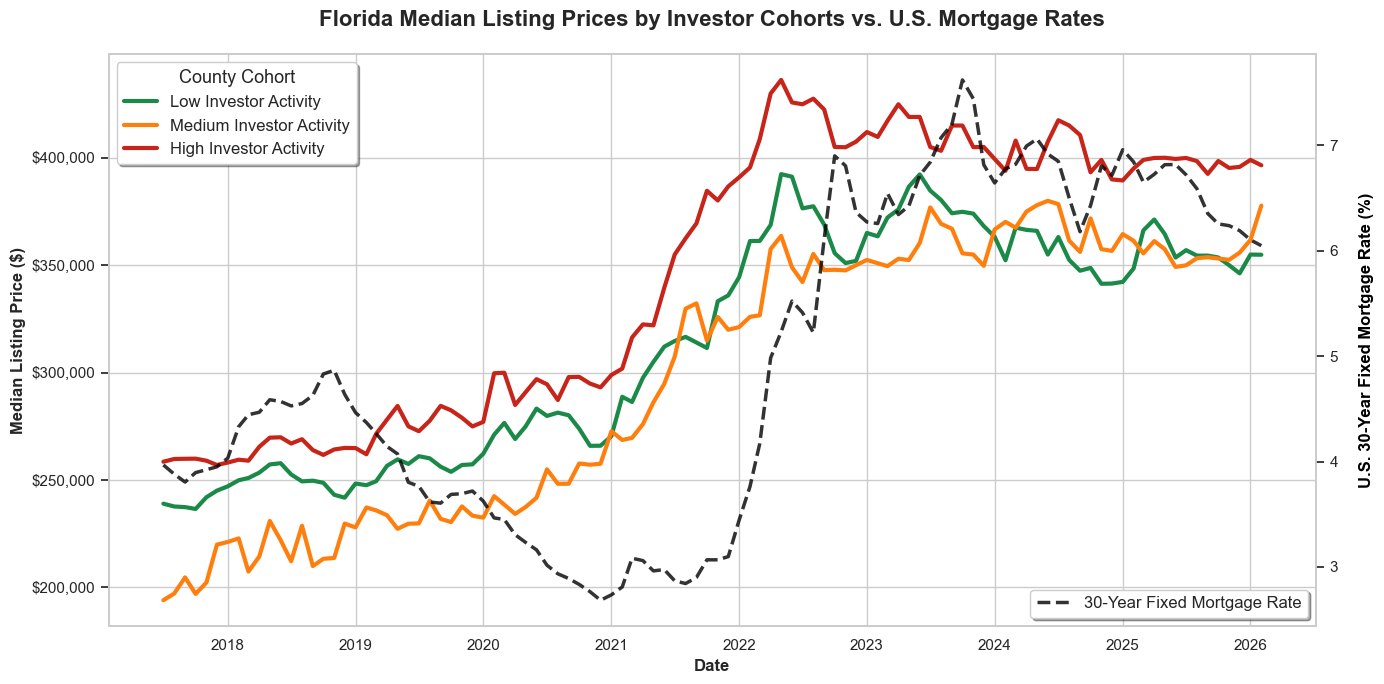

High Investor Zones
Total Florida counties falling in the 'High' activity tercile: 23
A few of the heaviest institutional targets:
 - Nassau (Typical Investor YoY Spikes: -0.61%)
 - Okaloosa (Typical Investor YoY Spikes: -0.61%)
 - Okeechobee (Typical Investor YoY Spikes: -0.61%)
 - Orange (Typical Investor YoY Spikes: -0.61%)
 - Osceola (Typical Investor YoY Spikes: -0.61%)
 - Palm Beach (Typical Investor YoY Spikes: -0.61%)


In [12]:
# Filter explicitly for Florida
fl_df = df[df['state'] == 'fl'].copy()

# Determine the "Investor Activity Target" per County
# calculate the median historically to identify overarching patterns 
county_investor_scores = fl_df.dropna(subset=['Investor Purchases YoY']).groupby('county_name_x')['Investor Purchases YoY'].median().reset_index()
# Protect against duplicate edge-values (lots of exact 0%s) using a ranking system
county_investor_scores['Score_Rank'] = county_investor_scores['Investor Purchases YoY'].rank(method='first')

# divide the Florida counties into 3 even tiers
county_investor_scores['Investor Category'] = pd.qcut(
    county_investor_scores['Score_Rank'], 
    q=3, 
    labels=['Low Investor Activity', 'Medium Investor Activity', 'High Investor Activity']
)
# insert investor category tags into df
fl_df = fl_df.merge(county_investor_scores[['county_name_x', 'Investor Category']], on='county_name_x', how='inner')

# Group by Date and the 3 Categories to get median price for each cohort
cohort_trends = fl_df.groupby(['date', 'Investor Category'], observed=True)['median_listing_price_x'].median().reset_index()

# Mortgage rates are national (meaning identical for every county on any chosen date). Use .first() observation to prevent duplicating lines
rates_trend = fl_df.dropna(subset=['U.S. 30 year FRM']).groupby('date')['U.S. 30 year FRM'].first().reset_index()

# Build the Plot with Dual Y-Axes
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")
cohort_colors = {
    'High Investor Activity': '#c7241a',   # Red
    'Medium Investor Activity': '#ff7f0e', # Orange
    'Low Investor Activity': '#1b8a48'     # Green
}
# Plot the 3 Primary Price Lines on the Main Left Y-Axis
sns.lineplot(
    data=cohort_trends,
    x='date',
    y='median_listing_price_x',
    hue='Investor Category',
    palette=cohort_colors,
    linewidth=3,
    ax=ax1
)
# Create the Secondary Right Y-Axis
ax2 = ax1.twinx()
# Plot the Mortgage Rate Line overlaid on Axis 2
sns.lineplot(
    data=rates_trend,
    x='date',
    y='U.S. 30 year FRM',
    color='black',
    linewidth=2.5,
    linestyle='--', # Dashed to clearly separate it visually from the price bands
    alpha=0.8,
    ax=ax2,
    label='30-Year Fixed Mortgage Rate'
)
# Fix legend titles 
ax2.get_legend().remove()
# Formatting Main Left Y-Axis (Prices)
ax1.set_title('Florida Median Listing Prices by Investor Cohorts vs. U.S. Mortgage Rates', fontsize=16, pad=20, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Median Listing Price ($)', fontsize=12, fontweight='bold')
formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)
# Formatting Secondary Right Y-Axis (Rates)
ax2.set_ylabel('U.S. 30-Year Fixed Mortgage Rate (%)', fontsize=12, fontweight='bold', color='black', labelpad=15)
ax2.grid(False) # Turn off the background grid for the secondary axis so the main visual grid lines don't get messy
# Legend Placements 
ax1.legend(title='County Cohort', title_fontsize='13', fontsize='12', loc='upper left', frameon=True, shadow=True)
ax2.legend(loc='lower right', frameon=True, fontsize='12', shadow=True)
plt.tight_layout()
plt.show()

# counties categorized in the "High" bucket for context
high_activity_counties = county_investor_scores[county_investor_scores['Investor Category'] == 'High Investor Activity']
print("High Investor Zones")
print(f"Total Florida counties falling in the 'High' activity tercile: {len(high_activity_counties)}")
print("A few of the heaviest institutional targets:")
top_samples = high_activity_counties.sort_values(by='Investor Purchases YoY', ascending=False).head(6)
for index, row in top_samples.iterrows():
    # Capitalizes the county name strings dynamically 
    county_clean = str(row['county_name_x']).title().replace(", Fl", "")
    print(f" - {county_clean} (Typical Investor YoY Spikes: {row['Investor Purchases YoY']:.2f}%)")

Zivot-Andrews Test: Florida Trend
Z-Statistic: -3.7759  |  p-value: 0.6513
Identified Structural Break Date: August 2022
Zivot-Andrews Test: US (minus FL) Trend
Z-Statistic: -4.1933  |  p-value: 0.3781
Identified Structural Break Date: January 2019


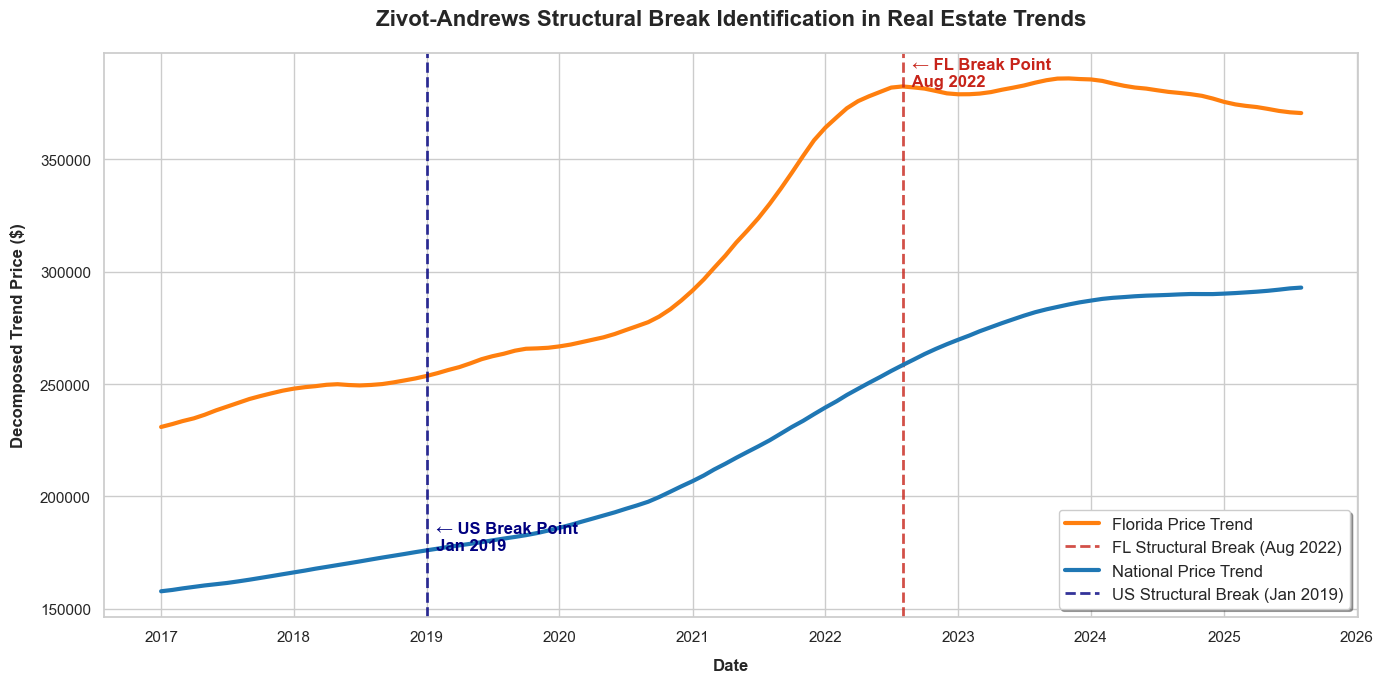

In [15]:
# take trend components from your earlier decomposition
# Using .dropna() shaves off the missing ends caused by the moving average decomposition window
fl_trend_clean = dec_fl.trend.dropna()
rest_trend_clean = dec_rest.trend.dropna()

# Setup the Zivot-Andrews Test Engine
def run_za_test(series, name):
    # look for a structural break in both the intercept (a sudden jump in prices) 
    # and the trend itself (a sudden change in market momentum/slope)
    res = zivot_andrews(series, regression='ct')
    
    z_stat = res[0]
    p_value = res[1]
    break_idx = res[4] # This specific index object isolates the exact structural break 
    
    # Map the algorithmic break index back to the chronological date index
    break_date = series.index[break_idx]
    
    print(f"Zivot-Andrews Test: {name}")
    print(f"Z-Statistic: {z_stat:.4f}  |  p-value: {p_value:.4f}")
    print(f"Identified Structural Break Date: {break_date.strftime('%B %Y')}")
        
    return break_date, p_value

# Execute the Tests
break_date_fl, p_fl = run_za_test(fl_trend_clean, "Florida Trend")
break_date_rest, p_rest = run_za_test(rest_trend_clean, "US (minus FL) Trend")


# Build the Visual Output
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Render Florida
plt.plot(fl_trend_clean.index, fl_trend_clean, color='#ff7f0e', linewidth=3, label='Florida Price Trend')

# Break Line for Florida
plt.axvline(break_date_fl, color='#c7241a', linestyle='--', linewidth=2, alpha=0.8,
            label=f'FL Structural Break ({break_date_fl.strftime("%b %Y")})')

# Annotate the break explicitly on the Florida curve's path
y_pos_fl = fl_trend_clean.loc[break_date_fl]
plt.text(break_date_fl, y_pos_fl, f'  ← FL Break Point\n  {break_date_fl.strftime("%b %Y")}', 
         color='#c7241a', fontweight='bold', fontsize=12)


# Render Rest of Nation
plt.plot(rest_trend_clean.index, rest_trend_clean, color='#1f77b4', linewidth=3, label='National Price Trend')

# Break Line for the Rest of the US
plt.axvline(break_date_rest, color='navy', linestyle='--', linewidth=2, alpha=0.8,
            label=f'US Structural Break ({break_date_rest.strftime("%b %Y")})')

# Annotate the break explicitly on the National curve's path
y_pos_rest = rest_trend_clean.loc[break_date_rest]
plt.text(break_date_rest, y_pos_rest, f'  ← US Break Point\n  {break_date_rest.strftime("%b %Y")}', 
         color='navy', fontweight='bold', fontsize=12)


# Formatting Print
plt.title('Zivot-Andrews Structural Break Identification in Real Estate Trends', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Decomposed Trend Price ($)', fontsize=12, fontweight='bold', labelpad=10)
plt.xlabel('Date', fontsize=12, fontweight='bold', labelpad=10)

plt.legend(loc='lower right', frameon=True, fontsize=12, shadow=True)
plt.tight_layout()
plt.show()


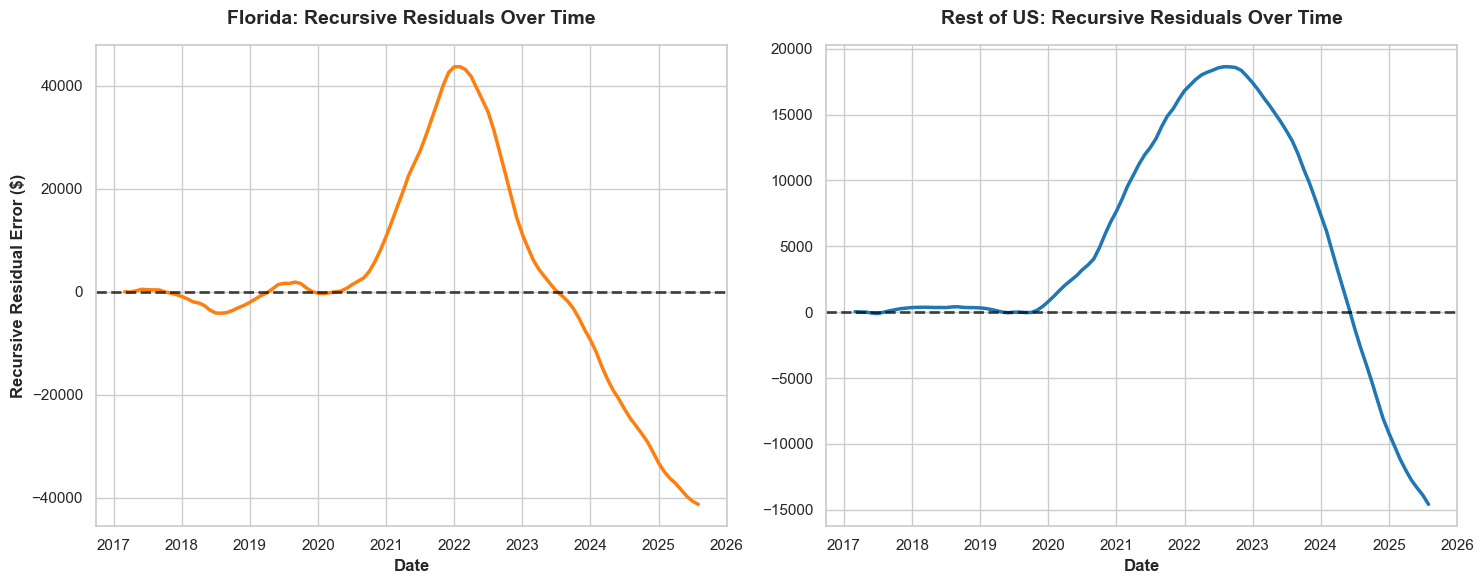

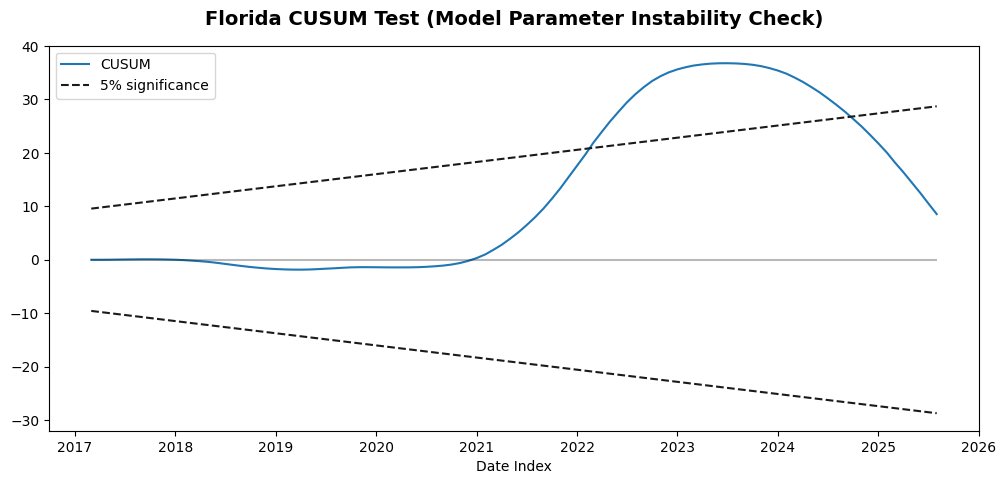

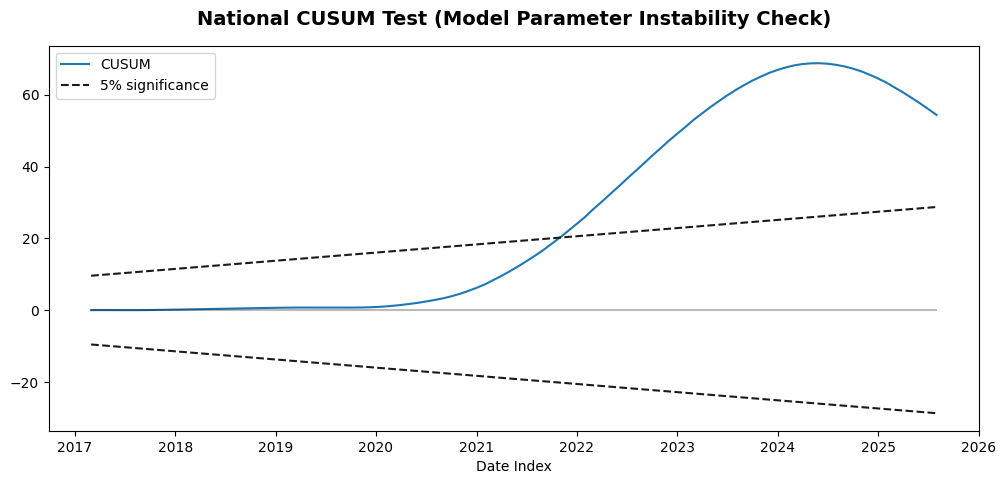

In [ ]:
# Prepare Variables 
# build a regression baseline containing a constant and a linear time index [0, 1, 2...]
exog_fl = sm.add_constant(np.arange(len(fl_trend_clean)))
exog_rest = sm.add_constant(np.arange(len(rest_trend_clean)))

# Fit the Recursive Least Squares (RLS) Models
# RLS iteratively updates the regression one month at a time, capturing the newly generated residuals
rls_fl = sm.RecursiveLS(fl_trend_clean, exog_fl)
res_fl = rls_fl.fit()

rls_rest = sm.RecursiveLS(rest_trend_clean, exog_rest)
res_rest = rls_rest.fit()


# Create the Recursive Residual Plot
# first 2 observations initialize the 2-parameter model
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Florida Residuals
plt.subplot(1, 2, 1)
plt.plot(fl_trend_clean.index[2:], res_fl.resid_recursive[2:], color='#ff7f0e', linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
plt.title('Florida: Recursive Residuals Over Time', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Recursive Residual Error ($)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')

# Rest of US Residuals
plt.subplot(1, 2, 2)
plt.plot(rest_trend_clean.index[2:], res_rest.resid_recursive[2:], color='#1f77b4', linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
plt.title('Rest of US: Recursive Residuals Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# Generate CUSUM plots (Cumulative Sum of Recursive Residuals)
sns.reset_orig() # Temporarily dropping Seaborn styling so Statsmodels renders the strict mathematical bounds cleanly

# Florida CUSUM
fig_fl = plt.figure(figsize=(12, 5))
res_fl.plot_cusum(fig=fig_fl)
plt.title('Florida CUSUM Test (Model Parameter Instability Check)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date Index')
plt.show()

# Rest of Nation CUSUM
fig_rest = plt.figure(figsize=(12, 5))
res_rest.plot_cusum(fig=fig_rest)
plt.title('National CUSUM Test (Model Parameter Instability Check)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date Index')
plt.show()
